# Data preparation

In [4]:
import os
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from google.colab import auth
from google.cloud import bigquery, storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Authenticate and set up environment
auth.authenticate_user()
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
!gcloud config set project {project_id}

# Initialize BigQuery client
client = bigquery.Client(project=project_id)

# Initialize GCP Storage client with user_project parameter
storage_client = storage.Client(project=project_id)
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name, user_project=project_id)

# Path to the filtered combined data CSV in your GCP bucket
filtered_data_path = 'final_combined_data.csv'
filtered_blob = bucket.blob(filtered_data_path)

# Download the filtered combined data CSV to a local temporary file
local_filtered_data_path = '/tmp/final_combined_data.csv'
filtered_blob.download_to_filename(local_filtered_data_path)

# Load the filtered combined data CSV into a DataFrame
df = pd.read_csv(local_filtered_data_path)


# Extract embedding vectors
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
print (embeddings)
avg_peep = df['avg_peep']
print(avg_peep)

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
avg_peep = df['avg_peep']
mortality = df['icu_mort']

# Create a binary variable for avg_peep levels
df['high_peep'] = (df['avg_peep'] >= 10).astype(int)
peep_binary = df['high_peep']

# Define the four categories based on 'high_peep' and 'icu_mort'
high_peep_death = df[(df['high_peep'] == 1) & (df['icu_mort'] == 1)]
high_peep_survival = df[(df['high_peep'] == 1) & (df['icu_mort'] == 0)]
low_peep_death = df[(df['high_peep'] == 0) & (df['icu_mort'] == 1)]
low_peep_survival = df[(df['high_peep'] == 0) & (df['icu_mort'] == 0)]

# Count the number of occurrences in each category
high_peep_death_count = len(high_peep_death)
high_peep_survival_count = len(high_peep_survival)
low_peep_death_count = len(low_peep_death)
low_peep_survival_count = len(low_peep_survival)

# Print the counts
print("High PEEP with Mortality = 1 (Death):", high_peep_death_count)
print("High PEEP with Mortality = 0 (Survival):", high_peep_survival_count)
print("Low PEEP with Mortality = 1 (Death):", low_peep_death_count)
print("Low PEEP with Mortality = 0 (Survival):", low_peep_survival_count)

Updated property [core/project].
      embedding_0  embedding_1  embedding_2  embedding_3  embedding_4  \
0       -1.740258    -0.782546     0.805217    -1.685203    -0.150928   
1       -0.911495    -0.515437     0.619245    -2.373145    -0.171805   
2       -1.034045    -0.783105     0.583782    -1.079196     0.196727   
3       -1.498975    -0.566318     0.506368    -1.586067     0.069659   
4       -0.716697    -0.587135     1.320426    -2.036464    -0.071745   
...           ...          ...          ...          ...          ...   
1112    -1.295518    -0.371794     0.170809    -2.018295     0.624668   
1113    -0.767546    -0.130139     0.142088    -2.607982    -0.953248   
1114    -0.091549    -1.316677     0.362403    -2.207046     0.192631   
1115     0.394565    -0.205986     1.213435    -1.648330     0.394253   
1116    -0.996493    -1.363348     0.844462    -1.462523     0.076252   

      embedding_5  embedding_6  embedding_7  embedding_8  embedding_9  ...  \
0        0.5

In [5]:
# Randomly select 128 samples from each category
high_peep_death_sample = high_peep_death.sample(n=128, random_state=42)
high_peep_survival_sample = high_peep_survival.sample(n=128, random_state=42)
low_peep_death_sample = low_peep_death.sample(n=128, random_state=42)
low_peep_survival_sample = low_peep_survival.sample(n=128, random_state=42)

# Combine the samples into a single DataFrame
combined_samples = pd.concat([
    high_peep_death_sample,
    high_peep_survival_sample,
    low_peep_death_sample,
    low_peep_survival_sample
])

# Extract the embedding data from the combined samples
embedding_samples = combined_samples[embedding_columns]
# Split data into training and testing sets
X = combined_samples[embedding_columns + ['high_peep']]
y = combined_samples['icu_mort']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classifier (Random Forest as an example)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6310679611650486
Confusion Matrix:
 [[33 19]
 [19 32]]


In [6]:
# Randomly select 128 samples from each category
high_peep_death_sample = high_peep_death.sample(n=128, random_state=42)
high_peep_survival_sample = high_peep_survival.sample(n=128, random_state=42)
low_peep_death_sample = low_peep_death.sample(n=128, random_state=42)
low_peep_survival_sample = low_peep_survival.sample(n=128, random_state=42)

# Combine the samples into a single DataFrame
combined_samples = pd.concat([
    high_peep_death_sample,
    high_peep_survival_sample,
    low_peep_death_sample,
    low_peep_survival_sample
])

# Extract the embedding data from the combined samples
embedding_samples = combined_samples[embedding_columns]
# Split data into training and testing sets
X = combined_samples[embedding_columns + ['high_peep']]
y = combined_samples['icu_mort']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classifier (Random Forest as an example)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6310679611650486
Confusion Matrix:
 [[33 19]
 [19 32]]


# Simulator

In [7]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# Assuming combined_samples is already prepared and available
# combined_samples includes embedding_columns, high_peep, and icu_mort

# Step 1: Apply PCA to reduce dimensions to 62 components
pca = PCA(n_components=62, random_state=42)
X_pca = pca.fit_transform(combined_samples[embedding_columns])

# Step 2: Apply t-SNE to further reduce dimensions to 2 components
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# Step 3: Create a DataFrame for the t-SNE components
tsne_columns = [f'tsne_{i+1}' for i in range(2)]
X_tsne_df = pd.DataFrame(X_tsne, columns=tsne_columns, index=combined_samples.index)

# Step 4: Combine t-SNE components and PEEP values
X_tsne_df['high_peep'] = combined_samples['high_peep']

# Step 5: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_tsne_df, combined_samples['icu_mort'], test_size=0.2, random_state=42)

# Step 6: Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 7: Simulate survival probability under High and Low PEEP for each patient in the test set
X_test_high_peep = X_test.copy()
X_test_high_peep['high_peep'] = 1

X_test_low_peep = X_test.copy()
X_test_low_peep['high_peep'] = 0

# Predict probabilities for both scenarios
prob_high_peep = model.predict_proba(X_test_high_peep)[:, 0]  # Probability of survival (icu_mort = 0)
prob_low_peep = model.predict_proba(X_test_low_peep)[:, 0]    # Probability of survival (icu_mort = 0)

# Step 8: Output the results in a DataFrame
results = pd.DataFrame({
    'Patient Index': X_test.index,
    'Actual Avg PEEP': X_test['high_peep'].replace({1: 'High PEEP', 0: 'Low PEEP'}),
    'Predicted Survival Probability (High PEEP)': prob_high_peep,
    'Predicted Survival Probability (Low PEEP)': prob_low_peep,
    'Actual Outcome (Mortality)': y_test.replace({1: 'Death', 0: 'Survival'}),
    'Actual High PEEP': X_test['high_peep']
})

# Display the results
print(results)

      Patient Index Actual Avg PEEP  \
613             613        Low PEEP   
507             507        Low PEEP   
390             390        Low PEEP   
1008           1008       High PEEP   
36               36        Low PEEP   
...             ...             ...   
303             303        Low PEEP   
307             307       High PEEP   
721             721        Low PEEP   
776             776        Low PEEP   
101             101        Low PEEP   

      Predicted Survival Probability (High PEEP)  \
613                                         0.54   
507                                         0.53   
390                                         0.90   
1008                                        0.78   
36                                          0.26   
...                                          ...   
303                                         0.89   
307                                         0.69   
721                                         0.90   
776        

In [8]:
import os
import pandas as pd
from google.cloud import bigquery, storage

# Assuming 'results' DataFrame already exists from the previous code

# Calculate the difference in survival probability between High and Low PEEP
results['Survival Probability Difference'] = abs(results['Predicted Survival Probability (High PEEP)'] - results['Predicted Survival Probability (Low PEEP)'])

# Find the row with the largest difference in survival probability
max_diff_row = results.loc[results['Survival Probability Difference'].idxmax()]

# Save results to a CSV file
csv_filename = 'prediction_model_results.csv'
results.to_csv(csv_filename, index=False)

# Authenticate and set up environment
# Ensure you have authenticated with Google Cloud and set the correct project
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id

# Initialize GCP Storage client
storage_client = storage.Client(project=project_id)
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name, user_project=project_id)

# Upload the CSV file to the bucket
blob = bucket.blob(csv_filename)
blob.upload_from_filename(csv_filename)

print(f"File {csv_filename} uploaded to {bucket_name}.")

# Show the raw data row for the largest difference of survival percentage for high and low PEEP
print("Row with the largest difference in survival probability:")
print(max_diff_row)

# Calculate the difference in survival probability between High and Low PEEP
results['Survival Probability Difference'] = abs(results['Predicted Survival Probability (High PEEP)'] - results['Predicted Survival Probability (Low PEEP)'])

# Find the index of the row with the largest difference in survival probability
max_diff_index = results['Survival Probability Difference'].idxmax()

# Retrieve the corresponding row from 'results' DataFrame
max_diff_row = results.loc[max_diff_index]

# Retrieve the corresponding 'path' and 'dicom_id' from 'final_combined_data'
# Ensure 'final_combined_data' DataFrame has been loaded into 'df'
path_dicom_info = df.loc[max_diff_index, ['dicom_id', 'path']]

# Output the 'dicom_id' and 'path' columns
print("Corresponding Image Information for the Maximum Difference in Survival Probability:")
print(f"DICOM ID: {path_dicom_info['dicom_id']}")
print(f"Path: {path_dicom_info['path']}")

# Filter the results to include only patients with mortality = 1
mortality_1_results = results[results['Actual Outcome (Mortality)'] == 'Death']

# Calculate the difference in survival probability between High and Low PEEP for these patients
mortality_1_results['Survival Probability Difference'] = abs(mortality_1_results['Predicted Survival Probability (High PEEP)'] - mortality_1_results['Predicted Survival Probability (Low PEEP)'])

# Find the index of the row with the largest difference in survival probability among patients with mortality = 1
max_diff_index_mortality_1 = mortality_1_results['Survival Probability Difference'].idxmax()

# Retrieve the corresponding row from 'mortality_1_results' DataFrame
max_diff_row_mortality_1 = mortality_1_results.loc[max_diff_index_mortality_1]

# Retrieve the corresponding 'dicom_id' and 'path' from 'final_combined_data'
path_dicom_info_mortality_1 = df.loc[max_diff_index_mortality_1, ['dicom_id', 'path']]

# Output the 'dicom_id' and 'path' columns for the patient with mortality=1 and highest % difference
print("Corresponding Image Information for the Patient with Mortality=1 and Maximum Difference in Survival Probability:")
print(f"DICOM ID: {path_dicom_info_mortality_1['dicom_id']}")
print(f"Path: {path_dicom_info_mortality_1['path']}")


File prediction_model_results.csv uploaded to cxr_embedding.
Row with the largest difference in survival probability:
Patient Index                                       220
Actual Avg PEEP                               High PEEP
Predicted Survival Probability (High PEEP)         0.07
Predicted Survival Probability (Low PEEP)          0.85
Actual Outcome (Mortality)                        Death
Actual High PEEP                                      1
Survival Probability Difference                    0.78
Name: 220, dtype: object
Corresponding Image Information for the Maximum Difference in Survival Probability:
DICOM ID: 9d7db2f8-7eb7d5ff-c7c68164-ee515314-1372a1fc
Path: files/p14/p14338016/s51936058.txt
Corresponding Image Information for the Patient with Mortality=1 and Maximum Difference in Survival Probability:
DICOM ID: 9d7db2f8-7eb7d5ff-c7c68164-ee515314-1372a1fc
Path: files/p14/p14338016/s51936058.txt


<ipython-input-8-bbeb7bc50349>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mortality_1_results['Survival Probability Difference'] = abs(mortality_1_results['Predicted Survival Probability (High PEEP)'] - mortality_1_results['Predicted Survival Probability (Low PEEP)'])


# CXR image that is most off-predicted

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.8 MB/s eta 0:00:00


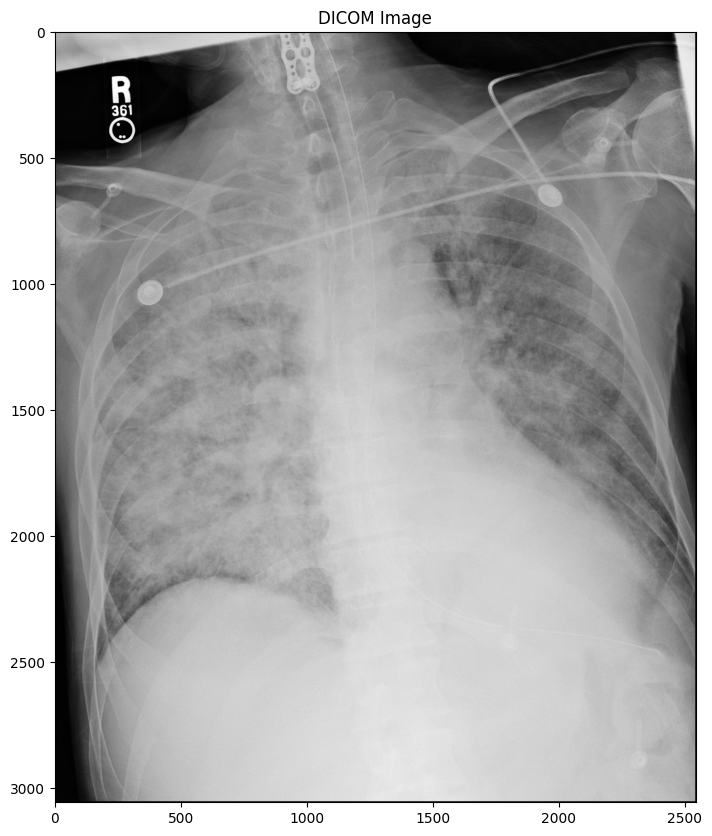

In [9]:
!pip install pydicom
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example1.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('Prediction_images/9d7db2f8-7eb7d5ff-c7c68164-ee515314-1372a1fc.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()